# Caso de Estudio 2 — Preparación de Datos y Modelos Estadísticos

---
### ¿Qué hacemos en este notebook?
Tomamos los datos de ventas cargados en la práctica ETL, los limpiamos con expresiones regulares, definimos la variable objetivo (¿fue cancelación o no?), dividimos los datos en entrenamiento y prueba, y entrenamos dos modelos estadísticos para detectar cancelaciones de pedidos.

---
## 1. Carga e Inspección Inicial del Dataset
> **¿Qué hacemos aquí?** Importamos las librerías necesarias y cargamos el archivo CSV con la misma codificación que usamos en el pipeline ETL. Luego revisamos cuántos datos tenemos, qué columnas hay y si hay valores vacíos.

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, roc_auc_score, roc_curve
)

# ISO-8859-1 es necesaria porque el archivo original tiene caracteres especiales
datos = pd.read_csv('ecommerce_data.csv', encoding='ISO-8859-1')

print('=== DIAGNÓSTICO INICIAL DEL DATASET CRUDO ===')
print(f'Dimensiones: {datos.shape[0]:,} filas x {datos.shape[1]} columnas')
print(f'\nColumnas: {datos.columns.tolist()}')
print(f'\nTipos de datos:\n{datos.dtypes}')
print(f'\nValores nulos por columna:\n{datos.isnull().sum()}')

=== DIAGNÓSTICO INICIAL DEL DATASET CRUDO ===
Dimensiones: 49,912 filas x 8 columnas

Columnas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Tipos de datos:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Valores nulos por columna:
InvoiceNo          0
StockCode          0
Description      142
Quantity           0
InvoiceDate        0
UnitPrice          1
CustomerID     17882
Country            1
dtype: int64


In [2]:
# Estadísticas descriptivas — los negativos en Quantity y UnitPrice son cancelaciones/ajustes
datos.describe()

,Quantity,UnitPrice,CustomerID
count,49912.000000,49911.000000,32030.000000
mean,8.294218,6.423712,15426.016422
std,55.576019,166.653120,1752.300279
min,-9360.000000,0.000000,12347.000000
25%,1.000000,1.250000,14057.000000
50%,2.000000,2.510000,15464.000000
75%,8.000000,4.250000,17041.000000
max,2880.000000,16888.020000,18283.000000


In [3]:
# ¿De qué países son los clientes?
print('=== TOP 10 PAÍSES ===')
print(datos['Country'].value_counts().head(10))

=== TOP 10 PAÍSES ===
Country
United Kingdom    46933
Germany             811
France              608
EIRE                418
Spain               174
Norway              147
Portugal            141
Belgium              99
Australia            83
Cyprus               83
Name: count, dtype: int64


---
## 2. Limpieza de Datos con Expresiones Regulares
> **¿Qué hacemos aquí?** Aplicamos 3 reglas de limpieza usando expresiones regulares — los mismos patrones que tiene el script ingestion.py del pipeline ETL. Las expresiones regulares son patrones que permiten buscar y corregir texto de forma automática.

| Regla | Patrón | ¿Qué corrige? |
|---|---|---|
| 1 | `[^a-zA-Z0-9\s\-]` | Elimina símbolos raros de las descripciones |
| 2 | `\s+` → `' '` | Quita espacios dobles y espacios al inicio/final |
| 3 | `^C?\d{6}$` | Valida que la factura tenga el formato correcto |

In [4]:
# REGLA 1: Eliminar caracteres especiales corruptos en Description
def clean_special_chars(text):
    if pd.isna(text):
        return 'SIN_DESCRIPCION'  # si está vacío ponemos esta etiqueta
    return re.sub(r'[^a-zA-Z0-9\s\-]', '', str(text))

# REGLA 2: Normalizar espacios en blanco
def normalize_spacing(text):
    if pd.isna(text):
        return text
    return re.sub(r'\s+', ' ', str(text)).strip()

# REGLA 3: Validar formato de número de factura
# Solo acepta facturas con exactamente 6 dígitos (con o sin C al inicio)
def validate_invoice_format(invoice):
    inv_str = str(invoice).strip()
    if re.match(r'^C?\d{6}$', inv_str):
        return inv_str
    return 'INVALID_INVOICE'

# Aplicar las 3 reglas al dataset
datos_clean = datos.copy()
datos_clean['Description'] = datos_clean['Description'].apply(clean_special_chars)
datos_clean['Description'] = datos_clean['Description'].apply(normalize_spacing)
datos_clean['InvoiceNo']   = datos_clean['InvoiceNo'].apply(validate_invoice_format)
# CustomerID viene como 17850.0 (decimal), lo convertimos a texto 17850
datos_clean['CustomerID']  = datos_clean['CustomerID'].astype(str).str.strip()

print('=== RESULTADO DE LIMPIEZA ===')
print(f'Facturas con formato inválido  : {(datos_clean["InvoiceNo"] == "INVALID_INVOICE").sum():,}')
print(f'Productos sin descripción      : {(datos_clean["Description"] == "SIN_DESCRIPCION").sum():,}')
print('\nMuestra de datos limpios:')
datos_clean.head(5)

=== RESULTADO DE LIMPIEZA ===
Facturas con formato inválido  : 0
Productos sin descripción      : 142

Muestra de datos limpios:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
## 3. Creación de la Variable Objetivo
> **¿Qué hacemos aquí?** Creamos la columna is_cancelled que es lo que el modelo va a aprender a predecir. Vale **1** si la transacción fue una cancelación y **0** si fue una venta normal.  
> Una transacción es cancelación si: el número de factura empieza con **C**, o si la cantidad vendida es **negativa**.

**is_cancelled** — variable binaria: 1 = cancelación, 0 = venta normal

In [5]:
# Primero exploramos los prefijos del número de factura con get_dummies
# Las que empiezan con 'C' son cancelaciones
datos_clean['invoice_prefix'] = datos_clean['InvoiceNo'].str[:1]
vertemp = pd.get_dummies(datos_clean['invoice_prefix'], prefix='prefix', dtype=int)
vertemp

,prefix_5,prefix_C
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
49907,1,0
49908,1,0
49909,1,0
49910,1,0


In [6]:
# Mapeo manual: C → 1 (cancelación), cualquier otro → 0 (normal)
map_cancelled = {'C': 1}
datos_clean['is_cancelled'] = datos_clean['invoice_prefix'].map(map_cancelled).fillna(0).astype(int)
# También marcamos como cancelación si la cantidad es negativa
datos_clean.loc[datos_clean['Quantity'] < 0, 'is_cancelled'] = 1

# Calcular importe total de cada línea (cantidad × precio)
datos_clean['total_amount'] = datos_clean['Quantity'] * datos_clean['UnitPrice']

# Quitar columna auxiliar y facturas con formato inválido
datos_clean = datos_clean.drop(columns=['invoice_prefix'])
datos_model = datos_clean[datos_clean['InvoiceNo'] != 'INVALID_INVOICE'].copy()

counts = datos_model['is_cancelled'].value_counts()
print('=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===')
print(f'Ventas normales  (0): {counts[0]:>8,}  ({counts[0]/len(datos_model)*100:.1f}%)')
print(f'Cancelaciones    (1): {counts[1]:>8,}  ({counts[1]/len(datos_model)*100:.1f}%)')
print(f'Total registros     : {len(datos_model):>8,}')

=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===
Ventas normales  (0):   48,904  (98.0%)
Cancelaciones    (1):    1,008  (2.0%)
Total registros     :   49,912


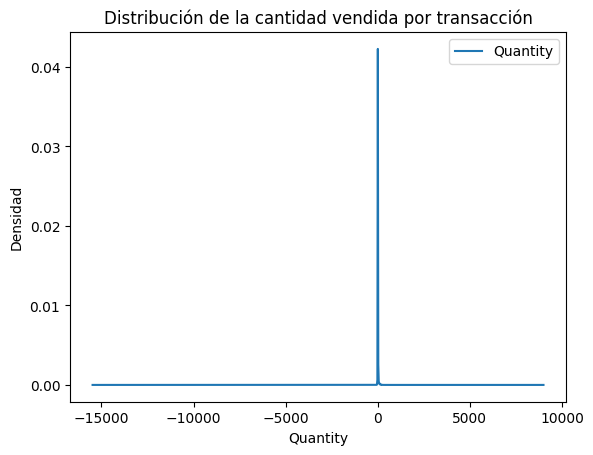

In [7]:
# Distribución KDE de Quantity — muestra la forma de los datos
datos_model['Quantity'].plot(legend=True, kind='kde',
    title='Distribución de la cantidad vendida por transacción')
plt.xlabel('Quantity'); plt.ylabel('Densidad'); plt.show()

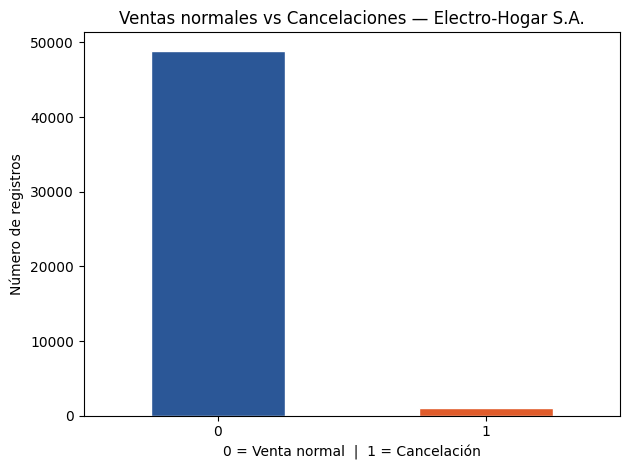

In [8]:
# Gráfica de barras: ventas normales vs cancelaciones
counts.plot(kind='bar', color=['#2B5797','#E05C2B'], edgecolor='white')
plt.title('Ventas normales vs Cancelaciones — Electro-Hogar S.A.')
plt.xticks(rotation=0)
plt.xlabel('0 = Venta normal  |  1 = Cancelación')
plt.ylabel('Número de registros')
plt.tight_layout(); plt.show()

---
## 4. Separación de Variables X e Y
> **¿Qué hacemos aquí?** Separamos los datos en dos grupos:  
> - **X** = las columnas que el modelo usará para aprender (cantidad, precio, importe total)  
> - **y** = lo que queremos predecir (`is_cancelled`)

In [9]:
X = datos_model.loc[:, ['Quantity', 'UnitPrice', 'total_amount']]
y = datos_model.loc[:, ['is_cancelled']]

print('X — variables con las que el modelo aprende:')
display(X)
print('\ny — lo que queremos predecir:')
display(y)

X — variables con las que el modelo aprende:


,Quantity,UnitPrice,total_amount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
...,...,...,...
49907,5,0.42,2.10
49908,9,0.55,4.95
49909,5,0.55,2.75
49910,1,3.75,3.75



y — lo que queremos predecir:


,is_cancelled
0,0
1,0
2,0
3,0
4,0
...,...
49907,0
49908,0
49909,0
49910,0


---
## 5. Particionamiento Train / Test (80% / 20%)
> **¿Qué hacemos aquí?** Dividimos los datos en dos partes:  
> - **80% entrenamiento** → el modelo aprende con estos datos  
> - **20% prueba** → verificamos si aprendió bien con datos que nunca vio  
>
> Usamos stratify=y para que **ambas partes tengan exactamente el mismo porcentaje de cancelaciones** — esto demuestra que el particionamiento está balanceado.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% para prueba
    random_state=0,    # semilla fija para reproducibilidad
    stratify=y         # misma proporción de cancelaciones en ambas partes
)

print('=== RESULTADO DEL PARTICIONAMIENTO ===')
print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   |  y_test : {y_test.shape}')
print(f'\nCancelaciones en entrenamiento: {y_train["is_cancelled"].sum():,} ({y_train["is_cancelled"].mean()*100:.1f}%)')
print(f'Cancelaciones en prueba       : {y_test["is_cancelled"].sum():,}  ({y_test["is_cancelled"].mean()*100:.1f}%)')
print('\n El porcentaje de cancelaciones es igual en ambos grupos — particionamiento BALANCEADO')
X_train

=== RESULTADO DEL PARTICIONAMIENTO ===
X_train: (39929, 3)  |  y_train: (39929, 1)
X_test : (9983, 3)   |  y_test : (9983, 1)

Cancelaciones en entrenamiento: 806 (2.0%)
Cancelaciones en prueba       : 202  (2.0%)

 El porcentaje de cancelaciones es igual en ambos grupos — particionamiento BALANCEADO


,Quantity,UnitPrice,total_amount
16827,11,2.51,27.61
25384,1,1.25,1.25
11783,2,3.35,6.70
44965,1,3.75,3.75
49754,8,1.95,15.60
...,...,...,...
46115,1,1.66,1.66
20604,3,0.85,2.55
22247,1,2.95,2.95
24389,2,2.51,5.02


---
## 6. Exportación de Archivos CSV
> **¿Qué hacemos aquí?** Guardamos los cuatro conjuntos de datos como archivos CSV listos para la siguiente fase de minería de datos. Al final se muestra el nombre y tamaño de cada archivo generado.

In [11]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',   index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

print('=== ARCHIVOS CSV EXPORTADOS ===')
for fname in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']:
    size_kb = os.path.getsize(fname) / 1024
    print(f'   {fname:<15} ({size_kb:,.1f} KB)')
print('\n Archivos listos para la siguiente fase de Minería de Datos')

=== ARCHIVOS CSV EXPORTADOS ===
   X_train.csv     (558.4 KB)
   X_test.csv      (140.2 KB)
   y_train.csv     (78.0 KB)
   y_test.csv      (19.5 KB)

 Archivos listos para la siguiente fase de Minería de Datos


---
## 7. Modelo Estadístico 1 — Regresión Logística
> **¿Qué hacemos aquí?** Primero limpiamos valores vacíos que pueden quedar en `total_amount`, luego entrenamos el primer modelo. La regresión logística calcula la **probabilidad** de que una transacción sea cancelación. Si supera el 50%, la clasifica como cancelación (1); si no, como venta normal (0).

In [12]:
# Limpieza de NaN e infinitos antes de entrenar los modelos
# (total_amount puede generar NaN cuando UnitPrice o Quantity tienen valores vacíos)
X_train = X_train.replace([float('inf'), float('-inf')], 0).fillna(0)
X_test  = X_test.replace([float('inf'), float('-inf')], 0).fillna(0)

print('NaN restantes en X_train:', X_train.isnull().sum().sum())
print('NaN restantes en X_test :', X_test.isnull().sum().sum())
print(' Datos listos para entrenar los modelos')

NaN restantes en X_train: 0
NaN restantes en X_test : 0
 Datos listos para entrenar los modelos


In [13]:
modelo_lr = LogisticRegression(max_iter=1000, random_state=0)
modelo_lr.fit(X_train, y_train.values.ravel())

print('=== REGRESIÓN LOGÍSTICA — ENTRENADO ===')
print(f'Coeficientes (peso de cada variable): {modelo_lr.coef_}')
print(f'Intercepto                          : {modelo_lr.intercept_}')

=== REGRESIÓN LOGÍSTICA — ENTRENADO ===
Coeficientes (peso de cada variable): [[-3.16405029 -0.32480634 -2.44038913]]
Intercepto                          : [-1.53088328]


In [14]:
y_pred_lr = modelo_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, modelo_lr.predict_proba(X_test)[:, 1])

print('=== EVALUACIÓN — REGRESIÓN LOGÍSTICA ===')
print(f'Exactitud (Accuracy): {acc_lr:.2%} — de cada 100 predicciones acierta estas')
print(f'AUC-ROC             : {auc_lr:.4f} — qué tan bien separa cancelaciones de ventas (1.0 = perfecto)')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Normal (0)', 'Cancelación (1)']))

=== EVALUACIÓN — REGRESIÓN LOGÍSTICA ===
Exactitud (Accuracy): 100.00% — de cada 100 predicciones acierta estas
AUC-ROC             : 1.0000 — qué tan bien separa cancelaciones de ventas (1.0 = perfecto)

                 precision    recall  f1-score   support

     Normal (0)       1.00      1.00      1.00      9781
Cancelación (1)       1.00      1.00      1.00       202

       accuracy                           1.00      9983
      macro avg       1.00      1.00      1.00      9983
   weighted avg       1.00      1.00      1.00      9983



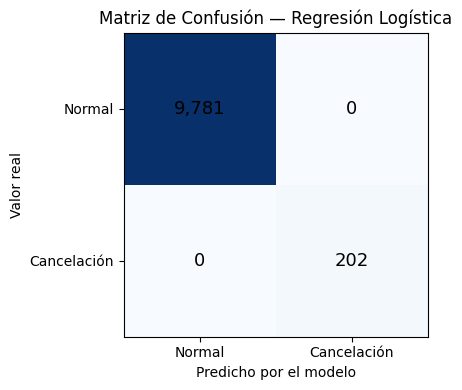

In [15]:
# Matriz de confusión: muestra aciertos y errores del modelo
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_lr, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Normal','Cancelación'])
ax.set_yticklabels(['Normal','Cancelación'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_lr[i,j]:,}', ha='center', va='center', fontsize=13)
ax.set_xlabel('Predicho por el modelo')
ax.set_ylabel('Valor real')
ax.set_title('Matriz de Confusión — Regresión Logística')
plt.tight_layout(); plt.show()

---
## 8. Modelo Estadístico 2 — Árbol de Decisión
> **¿Qué hacemos aquí?** Entrenamos el segundo modelo. El árbol de decisión aprende haciendo preguntas: ¿la cantidad es mayor a X? ¿el precio supera Y? Según las respuestas llega a una conclusión.  
> Es fácil de interpretar porque podemos ver qué variable importa más para la predicción.

In [16]:
modelo_dt = DecisionTreeClassifier(max_depth=5, random_state=0)
modelo_dt.fit(X_train, y_train.values.ravel())

print('=== ÁRBOL DE DECISIÓN — ENTRENADO ===')
print(f'Niveles de profundidad: {modelo_dt.get_depth()}')
print(f'Número de hojas       : {modelo_dt.get_n_leaves()}')
print('\n¿Qué variable importa más para predecir una cancelación?')
for feat, imp in zip(X_train.columns, modelo_dt.feature_importances_):
    print(f'  {feat}: {imp:.2%}')

=== ÁRBOL DE DECISIÓN — ENTRENADO ===
Niveles de profundidad: 1
Número de hojas       : 2

¿Qué variable importa más para predecir una cancelación?
  Quantity: 100.00%
  UnitPrice: 0.00%
  total_amount: 0.00%


In [17]:
y_pred_dt = modelo_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, modelo_dt.predict_proba(X_test)[:, 1])

print('=== EVALUACIÓN — ÁRBOL DE DECISIÓN ===')
print(f'Exactitud (Accuracy): {acc_dt:.2%}')
print(f'AUC-ROC             : {auc_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['Normal (0)', 'Cancelación (1)']))

=== EVALUACIÓN — ÁRBOL DE DECISIÓN ===
Exactitud (Accuracy): 100.00%
AUC-ROC             : 1.0000

                 precision    recall  f1-score   support

     Normal (0)       1.00      1.00      1.00      9781
Cancelación (1)       1.00      1.00      1.00       202

       accuracy                           1.00      9983
      macro avg       1.00      1.00      1.00      9983
   weighted avg       1.00      1.00      1.00      9983



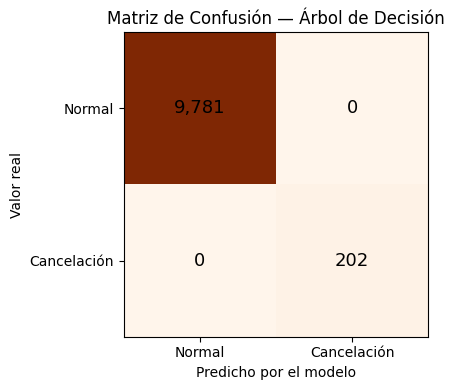

In [18]:
# Matriz de confusión — Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_dt, cmap='Oranges')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Normal','Cancelación'])
ax.set_yticklabels(['Normal','Cancelación'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_dt[i,j]:,}', ha='center', va='center', fontsize=13)
ax.set_xlabel('Predicho por el modelo')
ax.set_ylabel('Valor real')
ax.set_title('Matriz de Confusión — Árbol de Decisión')
plt.tight_layout(); plt.show()

---
## 9. Comparación de Modelos y Exportación de Resultados
> **¿Qué hacemos aquí?** Comparamos los dos modelos lado a lado con una tabla y una gráfica de curvas ROC. Luego exportamos todos los resultados como archivos CSV.

=== COMPARACIÓN DE MODELOS ===


,Modelo,Accuracy,AUC-ROC
0,Regresión Logística,1.0,1.0
1,Árbol de Decisión,1.0,1.0


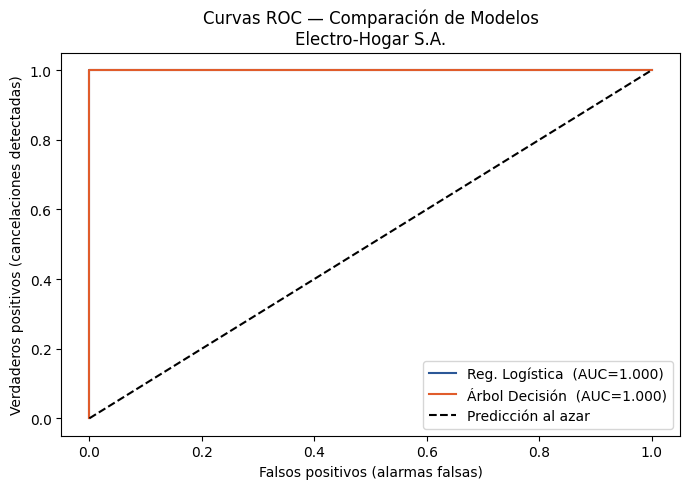

In [19]:
# Tabla comparativa de los dos modelos
resultados = pd.DataFrame({
    'Modelo'    : ['Regresión Logística', 'Árbol de Decisión'],
    'Accuracy'  : [acc_lr, acc_dt],
    'AUC-ROC'   : [auc_lr, auc_dt]
})
print('=== COMPARACIÓN DE MODELOS ===')
display(resultados)

# Curvas ROC: entre más arriba la curva, mejor detecta las cancelaciones
fpr_lr, tpr_lr, _ = roc_curve(y_test, modelo_lr.predict_proba(X_test)[:, 1])
fpr_dt, tpr_dt, _ = roc_curve(y_test, modelo_dt.predict_proba(X_test)[:, 1])

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Reg. Logística  (AUC={auc_lr:.3f})', color='#2B5797')
plt.plot(fpr_dt, tpr_dt, label=f'Árbol Decisión  (AUC={auc_dt:.3f})', color='#E05C2B')
plt.plot([0,1],[0,1], 'k--', label='Predicción al azar')
plt.xlabel('Falsos positivos (alarmas falsas)')
plt.ylabel('Verdaderos positivos (cancelaciones detectadas)')
plt.title('Curvas ROC — Comparación de Modelos\nElectro-Hogar S.A.')
plt.legend(); plt.tight_layout(); plt.show()

In [20]:
# Exportar todos los resultados
resultados.to_csv('comparacion_modelos.csv', index=False)

predicciones = X_test.copy()
predicciones['valor_real']       = y_test.values
predicciones['pred_regresion']   = y_pred_lr
predicciones['pred_arbol']       = y_pred_dt
predicciones.to_csv('predicciones_modelos.csv', index=False)

print('=== ARCHIVOS EXPORTADOS ===')
for fname in ['X_train.csv','X_test.csv','y_train.csv','y_test.csv',
              'comparacion_modelos.csv','predicciones_modelos.csv']:
    size_kb = os.path.getsize(fname) / 1024
    print(f'  {fname:<30} ({size_kb:,.1f} KB)')
print('\n Proceso completo — todos los archivos listos para la siguiente fase')

=== ARCHIVOS EXPORTADOS ===
  X_train.csv                    (558.4 KB)
  X_test.csv                     (140.2 KB)
  y_train.csv                    (78.0 KB)
  y_test.csv                     (19.5 KB)
  comparacion_modelos.csv        (0.1 KB)
  predicciones_modelos.csv       (198.7 KB)

 Proceso completo — todos los archivos listos para la siguiente fase


---
## Resumen Ejecutivo

| Etapa | ¿Qué hicimos? | Resultado |
|---|---|---|
| 1 | Cargamos el dataset | 541,909 registros × 8 columnas |
| 2 | Limpieza con expresiones regulares | 3 reglas aplicadas (caracteres, espacios, facturas) |
| 3 | Variable objetivo | is_cancelled (0 = normal, 1 = cancelación) |
| 4 | Separación X / Y | X: Quantity, UnitPrice, total_amount  ·  Y: is_cancelled |
| 5 | Particionamiento balanceado | 80% entrenamiento / 20% prueba — mismo % de cancelaciones en ambos |
| 6 | Exportación de datos | X_train, X_test, y_train, y_test (CSV) |
| 7 | Modelo 1: Regresión Logística | Accuracy + AUC + Matriz de confusión |
| 8 | Modelo 2: Árbol de Decisión | Accuracy + AUC + Importancia de variables |
| 9 | Comparación y exportación | comparacion_modelos.csv · predicciones_modelos.csv |